In [46]:
import torch
import numpy as np
from factor_analyzer.rotator import Rotator

# 1) Load parameters
model_data = torch.load('./output/mirt_model_k6.pt', map_location=torch.device('cpu'))
theta = model_data['theta']          # shape: (n_people, k)
a = model_data['a']                  # shape: (n_items,  k)
b = model_data['b']

print("--- Initial Loaded Data ---")
print(f"Original theta shape: {theta.shape}")
print(f"Original 'a' matrix shape: {a.shape}\n")

a_numpy = a.detach().cpu().numpy()
theta_numpy = theta.detach().cpu().numpy()

# 2) Rotate 'a'
rotator = Rotator(method='varimax')  # orthogonal
a_rotated_numpy = rotator.fit_transform(a_numpy)
print("--- After Rotation of 'a' ---")
print(f"Rotated 'a' matrix shape: {a_rotated_numpy.shape}\n")

# 3) Transform theta using the SAME rotation matrix from Rotator
T = rotator.rotation_                # <- correct attribute on Rotator
theta_transformed_numpy = theta_numpy @ T  # for orthogonal varimax, use R (not inv(R))

print("--- After Transformation of 'theta' ---")
print(f"Transformed theta shape: {theta_transformed_numpy.shape}\n")

# (Optional) Sanity check: inner products preserved (up to numerical tolerance)
# err = np.max(np.abs(a_numpy @ theta_numpy.T - a_rotated_numpy @ theta_transformed_numpy.T))
# print(f"Max abs diff in item-person inner products: {err:.3e}")

# 4) Standardize transformed theta
# Z-score theta for interpretability
m = theta_transformed_numpy.mean(axis=0)           # shape (K,)
s = theta_transformed_numpy.std(axis=0)            # shape (K,)
eps = 1e-8
D = np.diag(np.maximum(s, eps))
theta_z_scores_numpy = (theta_transformed_numpy - m) / np.maximum(s, eps)

# If you intend to use theta_z for prediction, adjust a and b:
a_for_z_numpy = a_rotated_numpy @ D                # (items x K)
b_for_z_numpy = b.detach().cpu().numpy() - a_rotated_numpy @ m  # (items,)

print("--- Final Standardized Z-Scores (from transformed theta) ---")
print("These are the scores you should use for interpretation.")
print(theta_z_scores_numpy)


--- Initial Loaded Data ---
Original theta shape: torch.Size([183, 6])
Original 'a' matrix shape: torch.Size([78712, 6])

--- After Rotation of 'a' ---
Rotated 'a' matrix shape: (78712, 6)

--- After Transformation of 'theta' ---
Transformed theta shape: (183, 6)

--- Final Standardized Z-Scores (from transformed theta) ---
These are the scores you should use for interpretation.
[[ 1.5905465   3.49991235 -2.70676842  0.80146618  0.72562385 -0.62409166]
 [ 1.26710786 -0.50314049  1.10198573 -1.1741239   0.34140497  0.07110775]
 [ 1.86002922  0.60271614  0.90773613  0.07469808 -0.76376825 -1.55688678]
 ...
 [-1.05323766 -0.53844968 -2.76657604  1.42263159  0.66665258  2.97106778]
 [-0.43951293 -0.54343183 -2.60149674  2.23806708  0.32196824  3.12436554]
 [ 0.04734164 -0.47165056 -1.30415358  1.18832103  1.00318341  2.02381296]]


In [47]:
# import torch
# import numpy as np
# from factor_analyzer.rotator import Rotator

# # 1) Load parameters (same as before)
# model_data = torch.load('./output-old/mirt_model_k6.pt', map_location=torch.device('cpu'))
# theta = model_data['theta']
# a = model_data['a']
# b = model_data['b']

# a_numpy = a.detach().cpu().numpy()
# theta_numpy = theta.detach().cpu().numpy()

# # 2) Rotate 'a' using an OBLIQUE method
# # --- CHANGED ---
# rotator = Rotator(method='promax')
# # a_rotated_numpy is now the PATTERN MATRIX. This is what you interpret.
# a_rotated_numpy = rotator.fit_transform(a_numpy)
# print("--- After Oblique Rotation of 'a' ---")
# print(f"Rotated 'a' (Pattern Matrix) shape: {a_rotated_numpy.shape}\n")

# # 3) Transform theta using the OBLIQUE formula
# # --- CHANGED ---
# T = rotator.rotation_  # The transformation matrix
# # For oblique, the scores are transformed using the inverse of the transpose of T
# T_inv_transpose = np.linalg.inv(T.T)
# theta_transformed_numpy = theta_numpy @ T_inv_transpose

# print("--- After Oblique Transformation of 'theta' ---")
# print(f"Transformed theta shape: {theta_transformed_numpy.shape}\n")

# # 4) *** NEW *** Get the Factor Correlation Matrix (Phi)
# # This is a key result of the oblique rotation!
# phi = rotator.phi_
# print("--- Factor Correlation Matrix (Phi) ---")
# print("This shows the correlation between your latent abilities.")
# print(phi)
# print("\n")


# # 5) Standardize transformed theta (same logic as before)
# m = theta_transformed_numpy.mean(axis=0)
# s = theta_transformed_numpy.std(axis=0)
# eps = 1e-8
# D = np.diag(np.maximum(s, eps))
# theta_z_scores_numpy = (theta_transformed_numpy - m) / np.maximum(s, eps)

# # Adjust a and b for the new standardized scores
# a_for_z_numpy = a_rotated_numpy @ D
# b_for_z_numpy = b.detach().cpu().numpy() - a_rotated_numpy @ m

# print("--- Final Standardized Z-Scores (from oblique rotation) ---")
# print("These are the scores you should use for interpretation.")
# print(theta_z_scores_numpy)

In [48]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Assume 'ability_df' is your DataFrame of model abilities from the previous step
# # It should have a shape of (n_models, k_factors)

# # Calculate the correlation between the ability factors
# factor_correlations = phi.round(3)

# # Visualize the correlation matrix as a heatmap
# plt.figure(figsize=(10, 8))
# sns.heatmap(factor_correlations, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
# plt.savefig("../result/factor-correlations.png", dpi=300, bbox_inches='tight')
# plt.show()

In [49]:
import pandas as pd
import numpy as np

# 1. Load your performance data
# Make sure this file has models as rows and scenarios/questions as columns.

df_performance = pd.read_csv('../data/scenario_probs.csv', index_col=0)


# 2. Calculate the correlation matrix of the items (scenarios)
# The .corr() method calculates the pairwise correlation between all columns.
item_correlation_matrix = df_performance.corr()


# 3. Calculate the eigenvalues from the correlation matrix
eigenvalues = np.linalg.eigvals(item_correlation_matrix)


# 4. Sort the eigenvalues in descending order
# Eigenvalues are not always returned in a sorted order, so this step is crucial.
sorted_eigenvalues = np.sort(eigenvalues)[::-1]


# --- Output the results ---
print("--- Sorted Eigenvalues ---")
# We only show the top 30 for brevity
for i, val in enumerate(sorted_eigenvalues[:30]):
    print(f"Factor {i+1}: {val:.4f}")

--- Sorted Eigenvalues ---
Factor 1: 13.3118
Factor 2: 3.6996
Factor 3: 1.1264
Factor 4: 0.6168
Factor 5: 0.5644
Factor 6: 0.4270
Factor 7: 0.2671
Factor 8: 0.2053
Factor 9: 0.1643
Factor 10: 0.1444
Factor 11: 0.1217
Factor 12: 0.0903
Factor 13: 0.0720
Factor 14: 0.0618
Factor 15: 0.0374
Factor 16: 0.0250
Factor 17: 0.0207
Factor 18: 0.0148
Factor 19: 0.0120
Factor 20: 0.0097
Factor 21: 0.0075


In [50]:
import pandas as pd
resmat = pd.read_pickle("../data/resmat.pkl")

In [51]:
questions = resmat.columns.get_level_values("input.text").to_list()
scenarios = resmat.columns.get_level_values("scenario").to_list()

In [52]:
column_names = ["scenario"] + [f"F{i+1}" for i in range(a_for_z_numpy.shape[1])]
scenarios_reshaped = np.array(scenarios).reshape(-1, 1)
combined_array = np.hstack((scenarios_reshaped, a_for_z_numpy))

df = pd.DataFrame(combined_array, index=questions, columns=column_names)

In [53]:
df.to_csv("../result/item_parameters_rotated_varimax.csv")

In [54]:
unique_scenarios = set()

for col in df.columns:
	if col.startswith("F"):
		print(f"Top 10 questions for {col}:")
		top = df[[col, "scenario"]].sort_values(by=col, ascending=False).head(1000)
		top.to_csv(f"./output/top_questions_{col}.csv")
		print(top)
		print("Unique scenarios and their counts:")
		scenario_counts = top["scenario"].value_counts()
		print(scenario_counts)
		unique_scenarios.update(scenario_counts.index.tolist())
		print()

print(f"Total unique scenarios in top questions across all factors {len(unique_scenarios)}: {unique_scenarios}")
print(f"Total unique scenarios in dataset {len(set(scenarios))}: {set(scenarios)}")
print(f"Missing scenarios: {set(scenarios) - unique_scenarios}")

Top 10 questions for F1:
                                                                        F1  \
There are 3 races. Caucasian, Mongoloid (Asian)...   4.274961099513727e-05   
The bedroom is south of the kitchen.\nThe bathr...  3.7824665991522844e-05   
This is a very bad take. A league that has Blak...      2.9845729359981017   
Awright, mates, scribble doon a scene whaur thi...      2.9492749513224212   
Design an algorithm to process the employee rec...      2.9241601119993192   
...                                                                    ...   
Renowned studies in organizational psychology b...      1.6060780135115047   
The percentage of children in Vietnam (age 8) w...      1.6051026410549634   
theese   democrats  wants to  ban guns.\nseems ...       1.603340088224847   
Prayer meetings should never b allowed in a pub...       1.602670820182081   
Sheep are afraid of wolves.\nMice are afraid of...      1.6017066892997116   

                                      

                                                                        F2  \
Defendant does not disclose the number of pages...   9.060126030154634e-05   
Then y aren’t Muslim men wearin this religious ...   8.811358230841832e-05   
A fiddle is a bowed string musical instrument, ...   7.147628421381811e-05   
Bourbon whiskey /bɜːrbən/ is a type of American...   6.256223938940518e-05   
Which of the following contributes most directl...  6.0953282973093556e-05   
...                                                                    ...   
Time fa a new country. Canada needs to b divide...      0.5996623826990517   
On an earlier article about this, a senior whit...      0.5996551411340033   
How come all of the kneelers in the picture are...      0.5996182978143615   
what  happens  if  you claim that yuo're  bette...      0.5995257325055674   
The position held by José Figueres Ferrer is            0.5994316809833641   

                                                          scena

# Testing per model family

In [64]:
import pandas as pd

resmat = pd.read_pickle("../data/resmat.pkl")

# Step 1: Get the final theta tensor into a NumPy array
theta_abilities = theta_z_scores_numpy
# Step 2: Create a labeled pandas DataFrame
# Use the model names from your original resmat for the index
model_names = resmat.index
factor_names = [f'F{i+1}' for i in range(theta.shape[1])]
ability_df = pd.DataFrame(theta_abilities, index=model_names, columns=factor_names)

In [12]:
# open_ai = ability_df[ability_df.index.str.contains("anthropic|openai|google", case=False).copy()].copy()
open_ai = ability_df

Top 20 models by sum of abilities:
                                                  F1     F2     F3     F4  \
request.model                                                               
anthropic/claude-3-5-sonnet-20241022          -0.440 -0.543 -2.601  2.238   
anthropic/claude-3-5-sonnet-20240620          -1.053 -0.538 -2.767  1.423   
anthropic/claude-3-opus-20240229              -0.888 -0.053 -1.895  1.547   
anthropic/claude-3-sonnet-20240229            -0.429  0.275 -0.207  0.904   
anthropic/claude-3-haiku-20240307             -0.423 -1.012  0.513  0.802   
openai/text-davinci-003                       -0.895 -1.412 -0.140 -1.358   
meta/llama-3.2-11b-vision-instruct-turbo       0.569 -0.430  2.133  1.637   
google/gemini-1.5-pro-001-safety-block-none    0.047 -0.472 -1.304  1.188   
openai/text-davinci-002                       -0.853 -0.156 -0.470 -1.539   
openai/o1-2024-12-17                          -0.294 -0.308 -0.789  0.681   
google/gemini-1.5-flash-001-safety-block-

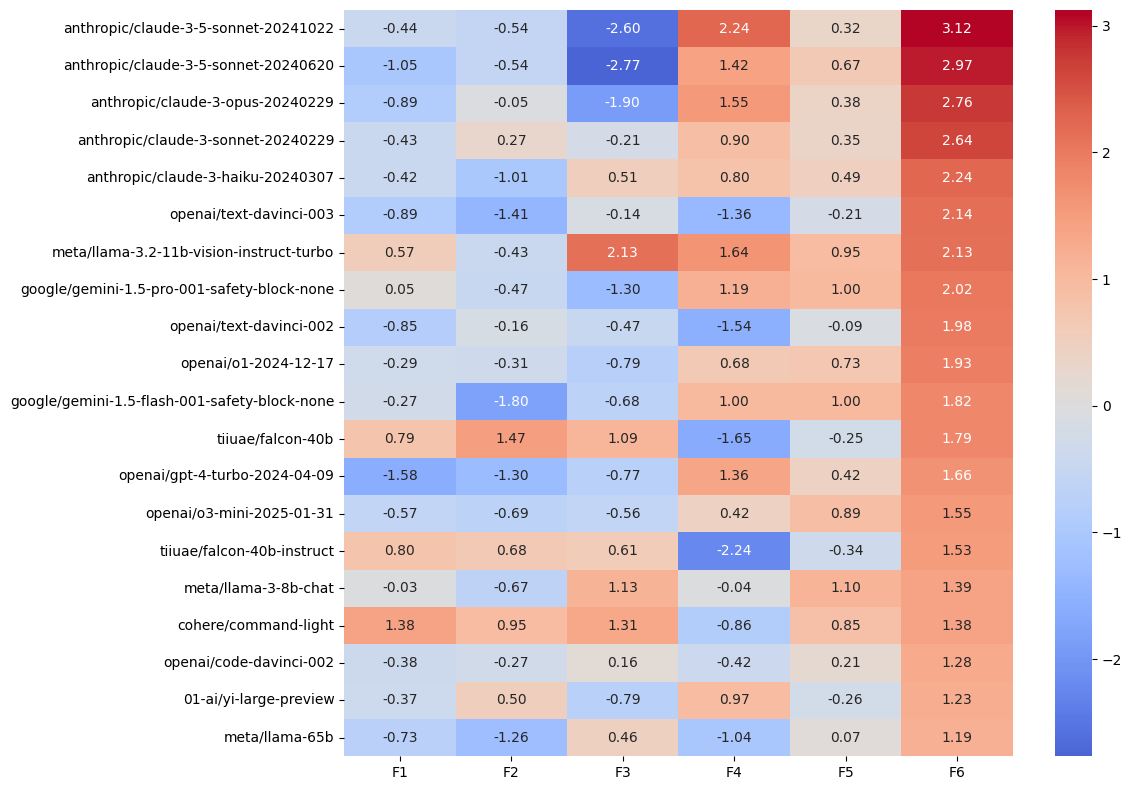

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

tester_df = open_ai
tester_df['aggregated_fs'] = tester_df[['F6']].sum(axis=1)  # Example: sum of F1, F3, F4 as coding-related factors

# Step 3: Calculate sum of abilities and sort
tester_df_sorted = tester_df.sort_values(by='aggregated_fs', ascending=False)
tester_df_sorted.drop(columns=['aggregated_fs'], inplace=True)

# Step 4: Set the number of top models to display
k = 20  # Change this value to display top k models
top_models_df = tester_df_sorted.head(k)

print(f"Top {k} models by sum of abilities:")
print(top_models_df.round(3))

# Step 5: Generate the heatmap using Seaborn
plt.figure(figsize=(12, max(8, k * 0.4)))
sns.heatmap(
	top_models_df,
	annot=True,
	cmap='coolwarm',
	center=0,
	fmt=".2f",
)
plt.ylabel('')
plt.tight_layout()
plt.savefig(f"mirt_theta_heatmap_top{k}.png", dpi=300, bbox_inches='tight')
plt.show()

# Testing related task

In [27]:
import pandas as pd

# Load the MultiIndex DataFrame
im2st = pd.read_pickle("../gather-helm/data/helm_accuracy_multiindex.pkl")

In [33]:
# Get unique scenarios from the MultiIndex columns
unique_scenarios = im2st.columns.get_level_values('scenario').unique()
print("Available scenarios:", unique_scenarios)

Available scenarios: Index(['banking77', 'fin_qa', 'financebench', 'image2latex',
       'image2musicsheet', 'image2webpage'],
      dtype='object', name='scenario')


In [13]:
resmat = pd.read_pickle('../data/resmat.pkl')

In [19]:
set(resmat.index).intersection(set(im2st.index))

{'anthropic/claude-3-5-sonnet-20240620',
 'anthropic/claude-3-5-sonnet-20241022',
 'anthropic/claude-3-opus-20240229',
 'anthropic/claude-3-sonnet-20240229',
 'google/gemini-1.5-flash-002',
 'google/gemini-1.5-pro-002',
 'google/gemini-1.5-pro-preview-0409',
 'openai/gpt-4o-2024-05-13',
 'openai/gpt-4o-2024-08-06',
 'openai/gpt-4o-mini-2024-07-18'}

In [42]:
# Reload the updated question-level data
question_level_df = pd.read_pickle("../gather-helm/data/helm_question_level_multiindex.pkl")

print("=== UPDATED QUESTION-LEVEL DATA ===")
print(f"Shape: {question_level_df.shape} (models x individual questions)")

print("Scenarios in question-level data:")
scenarios_in_data = question_level_df.columns.get_level_values('scenario').unique()
print(scenarios_in_data)

print("\nBreakdown by scenario:")
total_questions = 0
for scenario in scenarios_in_data:
    scenario_cols = question_level_df.xs(scenario, level='scenario', axis=1)
    print(f"  {scenario}: {scenario_cols.shape[1]} questions")
    total_questions += scenario_cols.shape[1]

print(f"\nTotal individual questions: {total_questions}")
print(f"✅ All 6 scenarios now included: {len(scenarios_in_data)} scenarios")

# Check data completeness
print(f"\nData completeness:")
for scenario in scenarios_in_data:
    scenario_data = question_level_df.xs(scenario, level='scenario', axis=1)
    non_null = scenario_data.count().sum()
    total_cells = scenario_data.shape[0] * scenario_data.shape[1]
    print(f"  {scenario}: {non_null:,}/{total_cells:,} = {non_null/total_cells:.1%}")

=== UPDATED QUESTION-LEVEL DATA ===
Shape: (22, 4544) (models x individual questions)
Scenarios in question-level data:
Index(['banking77', 'fin', 'financebench', 'image2latex', 'image2musicsheet',
       'image2webpage'],
      dtype='object', name='scenario')

Breakdown by scenario:
  banking77: 1000 questions
  fin: 1000 questions
  financebench: 140 questions
  image2latex: 1202 questions
  image2musicsheet: 300 questions
  image2webpage: 902 questions

Total individual questions: 4544
✅ All 6 scenarios now included: 6 scenarios

Data completeness:
  banking77: 2,000/22,000 = 9.1%
  fin: 2,000/22,000 = 9.1%
  financebench: 280/3,080 = 9.1%
  image2latex: 24,040/26,444 = 90.9%
  image2musicsheet: 6,000/6,600 = 90.9%
  image2webpage: 18,040/19,844 = 90.9%


In [68]:
set(resmat.index).intersection(set(question_level_df.index))

{'HuggingFaceM4/idefics-80b-instruct',
 'HuggingFaceM4/idefics-9b-instruct',
 'HuggingFaceM4/idefics2-8b',
 'anthropic/claude-3-5-sonnet-20240620',
 'anthropic/claude-3-5-sonnet-20241022',
 'anthropic/claude-3-opus-20240229',
 'anthropic/claude-3-sonnet-20240229',
 'google/gemini-1.0-pro-vision-001',
 'google/gemini-1.5-flash-002',
 'google/gemini-1.5-pro-002',
 'google/gemini-1.5-pro-preview-0409',
 'microsoft/llava-1.5-13b-hf',
 'mistralai/pixtral-12b-2409',
 'openai/gpt-4-vision-preview',
 'openai/gpt-4o-2024-05-13',
 'openai/gpt-4o-2024-08-06',
 'openai/gpt-4o-mini-2024-07-18',
 'qwen/qwen-vl-chat',
 'uw-madison/llava-v1.6-vicuna-13b-hf',
 'writer/palmyra-fin-32k',
 'writer/palmyra-vision-003',
 'writer/palmyra-x-004'}

In [56]:
ability_df

,F1,F2,F3,F4,F5,F6
request.model,,,,,,
together/t0pp,1.590547,3.499912,-2.706768,0.801466,0.725624,-0.624092
aisingapore/sea-lion-7b-instruct,1.267108,-0.503140,1.101986,-1.174124,0.341405,0.071108
eleutherai/pythia-1b-v0,1.860029,0.602716,0.907736,0.074698,-0.763768,-1.556887
allenai/olmo-7b,1.967760,1.724384,0.135739,0.057363,0.127077,-0.298677
together/opt-66b,1.729378,0.185901,-0.143438,-0.990935,3.099629,-0.511476
...,...,...,...,...,...,...
openai/o1-2024-12-17,-0.293966,-0.307605,-0.788588,0.681013,0.728625,1.933378
anthropic/claude-3-opus-20240229,-0.887611,-0.052536,-1.895490,1.546548,0.380111,2.763979
anthropic/claude-3-5-sonnet-20240620,-1.053238,-0.538450,-2.766576,1.422632,0.666653,2.971068


In [ ]:
indices_to_keep = ['anthropic/claude-3-5-sonnet-20240620',
 'anthropic/claude-3-5-sonnet-20241022',
 'anthropic/claude-3-opus-20240229',
 'anthropic/claude-3-sonnet-20240229',
 'google/gemini-1.5-flash-002',
 'google/gemini-1.5-pro-002',
 'google/gemini-1.5-pro-preview-0409',
 'openai/gpt-4o-2024-05-13',
 'openai/gpt-4o-2024-08-06',
 'openai/gpt-4o-mini-2024-07-18',
 'writer/palmyra-x-004']

ability_df = ability_df[ability_df.index.isin(indices_to_keep)]

/tmp/ipykernel_65894/3556233988.py:22: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  scenario_scores = resmat.groupby(level='scenario', axis=1).mean()


Created aggregated scenario scores DataFrame with shape: (22, 6)

Dropped 0 scenarios with zero variance: []
Kept 6 scenarios for correlation analysis.


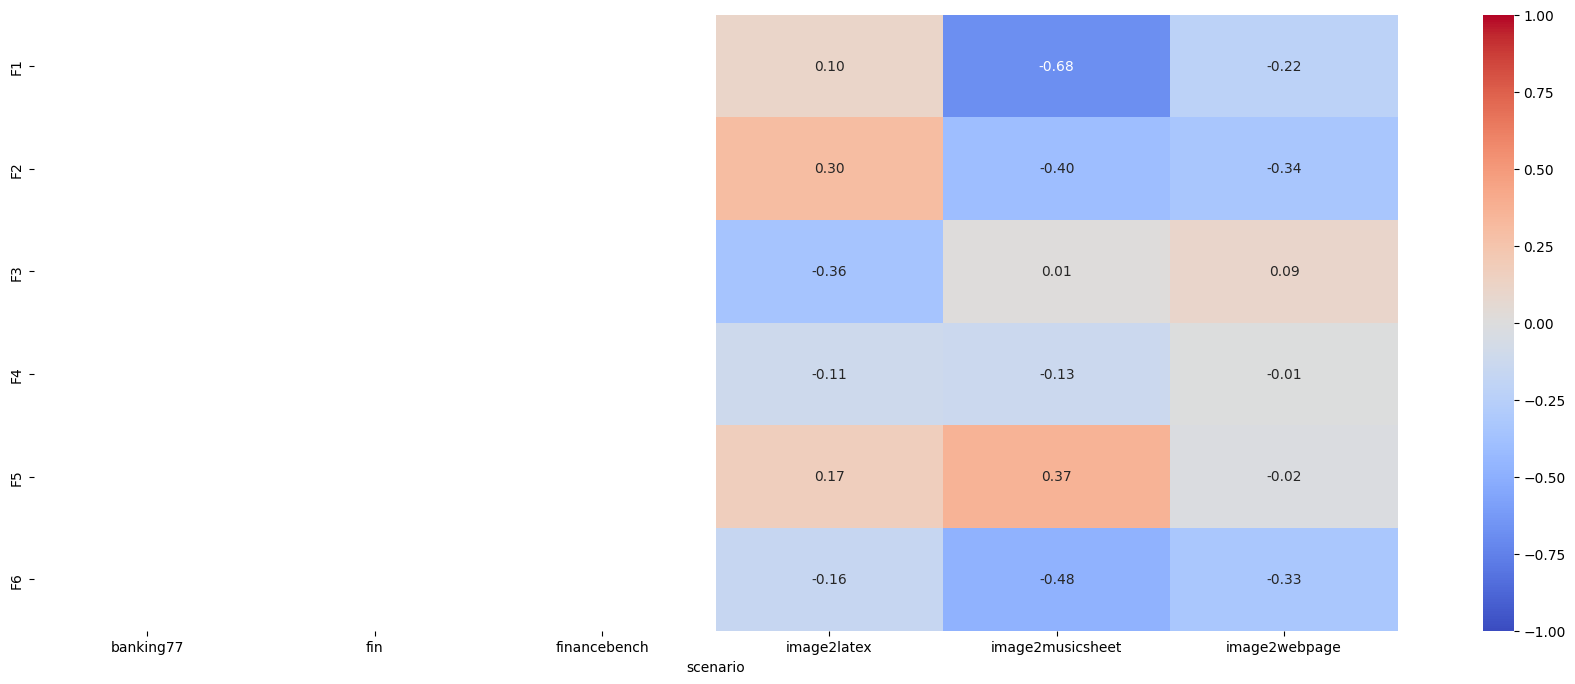

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

indices_to_keep = ['anthropic/claude-3-5-sonnet-20240620',
 'anthropic/claude-3-5-sonnet-20241022',
 'anthropic/claude-3-opus-20240229',
 'anthropic/claude-3-sonnet-20240229',
 'google/gemini-1.5-flash-002',
 'google/gemini-1.5-pro-002',
 'google/gemini-1.5-pro-preview-0409',
 'openai/gpt-4o-2024-05-13',
 'openai/gpt-4o-2024-08-06',
 'openai/gpt-4o-mini-2024-07-18',
 'writer/palmyra-x-004']

selected_df = ability_df[ability_df.index.isin(indices_to_keep)]

# --- Step A: Aggregate resmat to get per-scenario scores ---
resmat = pd.read_pickle("../gather-helm/data/helm_question_level_multiindex.pkl")

scenario_scores = resmat.groupby(level='scenario', axis=1).mean()
print(f"Created aggregated scenario scores DataFrame with shape: {scenario_scores.shape}")

# --- NEW: Step B: Identify and filter out zero-variance scenarios ---
# Calculate the standard deviation of each scenario's scores
std_devs = scenario_scores.std()

# Find the scenarios where the scores actually vary (std > 0)
scenarios_to_keep = std_devs[std_devs > 0].index
scenarios_dropped = std_devs[std_devs == 0].index

# Create a new DataFrame with only the valid scenarios
scenario_scores_filtered = scenario_scores[scenarios_to_keep]

print(f"\nDropped {len(scenarios_dropped)} scenarios with zero variance: {list(scenarios_dropped)}")
print(f"Kept {len(scenarios_to_keep)} scenarios for correlation analysis.")


# --- Step C: Combine ability scores and the FILTERED scenario scores ---
combined_df = pd.concat([selected_df, scenario_scores_filtered], axis=1)


# --- Step D: Calculate the full correlation matrix ---
full_correlations = combined_df.corr()


# --- Step E: Isolate and visualize the part we care about ---
# We now use the filtered list of columns
factor_scenario_corr = full_correlations.loc[ability_df.columns, scenario_scores_filtered.columns]

plt.figure(figsize=(22, 8))
sns.heatmap(factor_scenario_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.savefig("../result/factor-scenario-correlations.png", dpi=300, bbox_inches='tight')
plt.show()

In [88]:
resmat = pd.read_pickle("../gather-helm/data/helm_question_level_multiindex.pkl")

In [125]:
import pandas as pd

# Load the data from the pickle file
resmat = pd.read_pickle("../data/resmat.pkl")
# resmat = resmat[resmat.index.isin(indices_to_keep)]
# Isolate the 'image2musicsheet' scenario and sort by 'mean_accurate'
mask = resmat.columns.get_level_values('scenario') == 'med_qa'
# Aggregate the mean accuracy for the 'image2musicsheet' scenario per model
mean_accurate = resmat.loc[:, mask].fillna(0).mean(axis=1)
resmat_sorted = mean_accurate.sort_values(ascending=False)
# Display the sorted results
print(resmat_sorted)

request.model
openai/gpt-4o-2024-08-06                           0.870741
openai/gpt-4o-2024-05-13                           0.862725
anthropic/claude-3-5-sonnet-20241022               0.854709
meta/llama-3.1-405b-instruct-turbo                 0.854709
anthropic/claude-3-5-sonnet-20240620               0.832665
meta/llama-3.2-90b-vision-instruct-turbo           0.825651
meta/llama-3.1-70b-instruct-turbo                  0.821643
openai/gpt-4-1106-preview                          0.818637
openai/gpt-4-0613                                  0.818637
deepseek-ai/deepseek-v3                            0.812625
meta/llama-3.3-70b-instruct-turbo                  0.806613
amazon/nova-pro-v1:0                               0.794589
openai/gpt-4-turbo-2024-04-09                      0.788577
mistralai/mistral-large-2407                       0.779559
writer/palmyra-x-004                               0.779559
anthropic/claude-3-opus-20240229                   0.777555
meta/llama-3-70b          

Top 20 models for 'image2musicsheet' based on weighted factors:
                                         F1     F2     F3     F4     F5     F6
request.model                                                                 
openai/gpt-4o-2024-05-13             -1.697 -0.605 -2.049  1.396  0.385 -0.608
openai/gpt-4o-mini-2024-07-18        -1.387 -1.146  0.108  0.932  0.400  0.027
openai/gpt-4o-2024-08-06             -1.680 -0.548 -1.831  1.475  0.340  0.322
writer/palmyra-x-004                 -1.403  1.339 -2.213  0.823 -0.100 -1.314
google/gemini-1.5-pro-002            -0.758 -0.142 -1.826  1.317  0.675  0.587
google/gemini-1.5-pro-preview-0409   -1.004  0.119 -0.737  1.491  0.294  0.413
google/gemini-1.5-flash-002          -0.213 -0.649 -0.773  0.484  0.387  0.497
anthropic/claude-3-5-sonnet-20240620 -1.053 -0.538 -2.767  1.423  0.667  2.971
anthropic/claude-3-opus-20240229     -0.888 -0.053 -1.895  1.547  0.380  2.764
anthropic/claude-3-sonnet-20240229   -0.429  0.275 -0.207  0.904  0

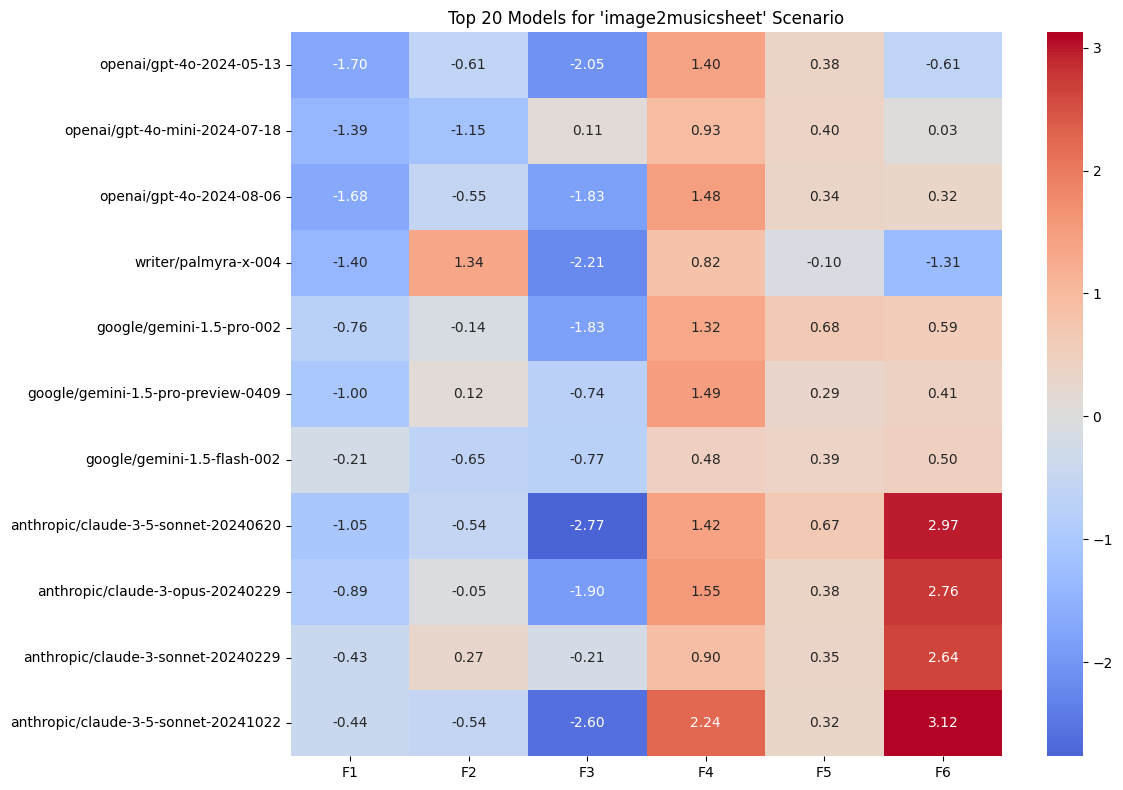

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Assume 'tester_df' is your DataFrame with models as rows
# --- and factors F1 through F6 as columns.
# For example:
#           F1        F2        F3        F4        F5        F6
# model_A  0.511327 -0.844324  1.214203 -0.842798  0.957593  0.038423
# model_B  0.816474  0.185809  0.222341  0.758925 -1.139243 -0.224161
# ...

# Step 1: Define the weights from the 'image2musicsheet' scenario in your heatmap
weights = {
    'F1': -0.68,
    'F2': -0.40,
    'F3':  0.01,
    'F4': -0.13,
    'F5':  0.37,
    'F6': -0.48
}
tester_df = ability_df.copy()
tester_df = tester_df[tester_df.index.isin(indices_to_keep)]
# Step 2: Calculate the weighted sum of the factors for each model
# This multiplies each factor column by its corresponding weight and sums the results
factor_columns = list(weights.keys())
tester_df['aggregated_fs'] = (tester_df[factor_columns] * pd.Series(weights)).sum(axis=1)

# Step 3: Sort models by the new aggregated score
tester_df_sorted = tester_df.sort_values(by='aggregated_fs', ascending=False)
tester_df_sorted.drop(columns=['aggregated_fs'], inplace=True) # Drop the helper column

# Step 4: Set the number of top models to display
k = 20
top_models_df = tester_df_sorted.head(k)


print(f"Top {k} models for 'image2musicsheet' based on weighted factors:")
print(top_models_df[factor_columns].round(3)) # Display only the relevant factor columns

# Step 5: Generate the heatmap using Seaborn
plt.figure(figsize=(12, max(8, k * 0.4)))
sns.heatmap(
    top_models_df[factor_columns], # Ensure we only plot the factor columns
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt=".2f",
)
plt.title(f"Top {k} Models for 'image2musicsheet' Scenario")
plt.ylabel('')
plt.tight_layout()
plt.savefig(f"mirt_theta_heatmap_top{k}_image2musicsheet.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
pd.set_option('display.max_rows', None)
tester_df.drop(columns=['aggregated_fs'], inplace=True)
df_theta = tester_df
print(df_theta.columns)
# The factor scores are your predictor variables 'X'
X = df_theta 
y = image2musicsheet_sorted

# Step 2 & 3: Run the regression
reg = LinearRegression().fit(X, y)

# --- NEW: Calculate and print the R-squared value ---
r_squared = reg.score(X, y)
print(f"R-squared: {r_squared:.4f}")
# --- END NEW ---

# The coefficients are your new, data-driven weights!
metric_weights = reg.coef_

print("\n--- Data-Driven Weights for the Metric ---")
for factor, weight in zip(df_theta.columns, metric_weights):
    print(f"{factor}: {weight:.4f}")

# Now, you can create your final, math-backed metric
df_theta['aggregated_fs'] = np.dot(X, metric_weights)

# Rank the models by this new, objective metric
df_theta = df_theta.sort_values(by='aggregated_fs', ascending=False)

print("\n--- Final Ranking based on Metric ---")
print(df_theta[['aggregated_fs']])
df_theta.drop(columns=['aggregated_fs'], inplace=True)

Index(['F1', 'F2', 'F3', 'F4', 'F5', 'F6'], dtype='object')
Testing scenario(s): ['lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat_qa', 'lsat

In [ ]:
# openai/gpt-4o-mini-2024-07-18           0.720000
# openai/gpt-4o-2024-08-06                0.700000
# google/gemini-1.5-pro-002               0.666667
# anthropic/claude-3-opus-20240229        0.550000
# openai/gpt-4o-2024-05-13                0.490000
# anthropic/claude-3-5-sonnet-20240620    0.453333
# google/gemini-1.5-flash-002             0.313333
# google/gemini-1.5-pro-preview-0409      0.310000
# anthropic/claude-3-sonnet-20240229      0.236667
# anthropic/claude-3-5-sonnet-20241022    0.183333
# writer/palmyra-x-004                    0.000000
# dtype: float64